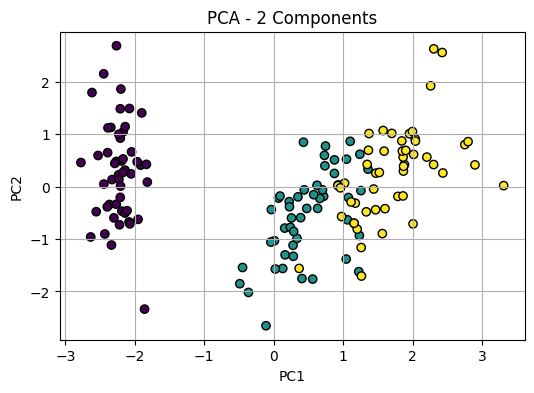

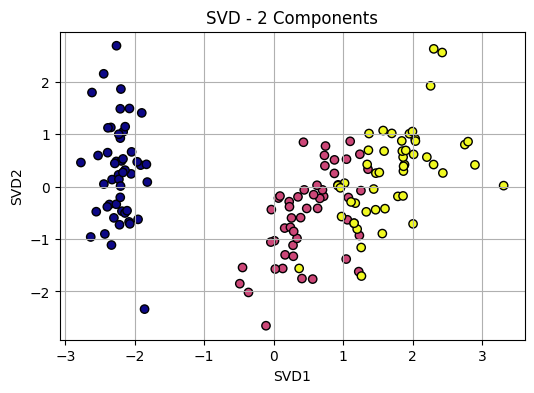

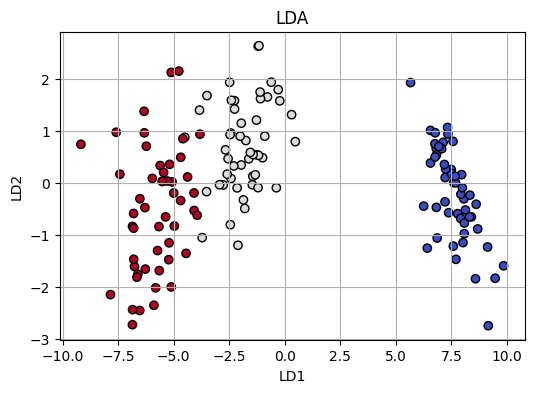

Selected feature indices (0-based): [2 3]


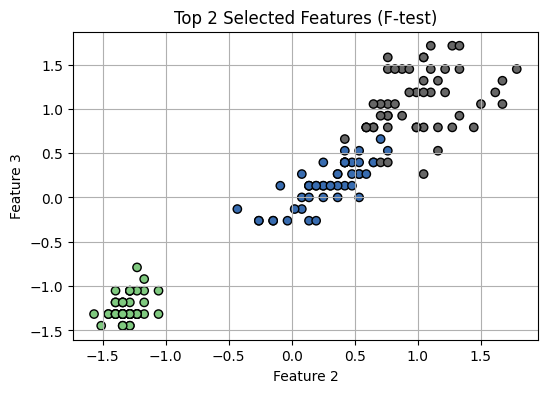

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

# Load a toy dataset (Iris)
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Principal Component Analysis (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA result
plt.figure(figsize=(6, 4))
plt.title("PCA - 2 Components")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

# 2. Singular Value Decomposition (SVD)
svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X_scaled)

# Plot SVD result
plt.figure(figsize=(6, 4))
plt.title("SVD - 2 Components")
plt.scatter(X_svd[:, 0], X_svd[:, 1], c=y, cmap='plasma', edgecolor='k')
plt.xlabel('SVD1')
plt.ylabel('SVD2')
plt.grid(True)
plt.show()

# 3. Linear Discriminant Analysis (LDA)
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# Plot LDA result
plt.figure(figsize=(6, 4))
plt.title("LDA")
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.grid(True)
plt.show()

# 4. Feature Subset Selection (ANOVA F-test)
selector = SelectKBest(score_func=f_classif, k=2)
X_selected = selector.fit_transform(X_scaled, y)
selected_indices = selector.get_support(indices=True)
print("Selected feature indices (0-based):", selected_indices)

# Plot selected features
plt.figure(figsize=(6, 4))
plt.title("Top 2 Selected Features (F-test)")
plt.scatter(X_selected[:, 0], X_selected[:, 1], c=y, cmap='Accent', edgecolor='k')
plt.xlabel(f"Feature {selected_indices[0]}")
plt.ylabel(f"Feature {selected_indices[1]}")
plt.grid(True)
plt.show()
